In [1]:
from video_io import get_video_info, get_frames
from viz import show_frame, show_keypoints

### 1 Input

In [2]:
video_path = "../data/bad.mp4"

In [3]:
info = get_video_info(video_path)
frames = get_frames(video_path)
print(frames)

[array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(720, 1280, 3), dtype=uint8), array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [

### 2 Perception

In [4]:
from ultralytics import YOLO
pose_model = YOLO("yolo26n-pose.pt")

In [5]:
processed_frames = pose_model.predict(frames, conf=0.25, verbose=False)
print(processed_frames)

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: ultralytics.engine.results.Keypoints object
masks: None
names: {0: 'person'}
obb: None
orig_img: array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
      

### 3 Signal

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ankle_coords(x_raw, y_raw, x_smooth, y_smooth, label="Ankle"):
    """
    Plot raw vs smoothed X/Y coordinates for a single ankle on one graph.

    Parameters:
        x_raw, y_raw       : raw (pre-interpolation/smoothing) coordinate arrays
        x_smooth, y_smooth : smoothed coordinate arrays
        label               : e.g. "Left Ankle" or "Right Ankle" (used in title)
    """
    frames = np.arange(len(x_smooth))

    plt.figure(figsize=(12, 5))

    # Raw (faded, background)
    plt.plot(frames, x_raw, alpha=0.3, color="tab:blue", linestyle="--", label="Raw X")
    plt.plot(frames, y_raw, alpha=0.3, color="tab:orange", linestyle="--", label="Raw Y")

    # Smoothed (main lines)
    plt.plot(frames, x_smooth, color="tab:blue", linewidth=2, label="Smoothed X")
    plt.plot(frames, y_smooth, color="tab:orange", linewidth=2, label="Smoothed Y")

    plt.xlabel("Frame")
    plt.ylabel("Pixel coordinate")
    plt.title(f"{label} Coordinates (Raw vs Smoothed)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [7]:
import numpy as np
from scipy.signal import savgol_filter

# YOLO keypoint indices (COCO format): 15 = left ankle, 16 = right ankle
LEFT_ANKLE, RIGHT_ANKLE = 15, 16

def extract_ankle_coords(processed_frames, ankle_idx, conf_thresh=0.5):
    """Pull x, y, conf for one ankle across all frames."""
    xs, ys, confs = [], [], []
    for result in processed_frames:
        if result.keypoints is None or len(result.keypoints.xy) == 0:
            xs.append(np.nan); ys.append(np.nan); confs.append(0)
            continue
        kp_xy = result.keypoints.xy[0]      # first detected person
        kp_conf = result.keypoints.conf[0]  # per-keypoint confidence

        x, y = kp_xy[ankle_idx].tolist()
        c = kp_conf[ankle_idx].item()

        if c < conf_thresh:
            xs.append(np.nan); ys.append(np.nan)  # mark low-confidence as missing
        else:
            xs.append(x); ys.append(y)
        confs.append(c)
    return np.array(xs), np.array(ys), np.array(confs)


def interpolate_missing(coords, label="coords"):
    """Fill NaNs (low-confidence/missing detections) via linear interpolation."""
    coords = coords.copy()
    nans = np.isnan(coords)
    n_missing = nans.sum()
    print(f"{label}: {n_missing} / {len(coords)} points interpolated "
          f"({n_missing/len(coords)*100:.1f}%)")
    if nans.any():
        idx = np.arange(len(coords))
        coords[nans] = np.interp(idx[nans], idx[~nans], coords[~nans])
    return coords


def smooth_coords(coords, window_length=7, polyorder=2):
    """Savitzky-Golay smoothing. window_length must be odd and > polyorder."""
    window_length = min(window_length, len(coords) if len(coords) % 2 == 1 else len(coords) - 1)
    return savgol_filter(coords, window_length=window_length, polyorder=polyorder)


In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_both_ankles(x_smooth_L, y_smooth_L, x_smooth_R, y_smooth_R):
    """
    Plot smoothed X/Y coordinates for both ankles on one combined graph.

    Parameters:
        x_smooth_L, y_smooth_L : smoothed left ankle coordinate arrays
        x_smooth_R, y_smooth_R : smoothed right ankle coordinate arrays
    """
    frames = np.arange(len(x_smooth_L))

    plt.figure(figsize=(12, 5))

    # Left ankle
    plt.plot(frames, x_smooth_L, color="tab:blue", linewidth=2, label="Left Ankle X")
    # plt.plot(frames, y_smooth_L, color="tab:cyan", linewidth=2, label="Left Ankle Y")

    # Right ankle
    plt.plot(frames, x_smooth_R, color="tab:red", linewidth=2, label="Right Ankle X")
    # plt.plot(frames, y_smooth_R, color="tab:orange", linewidth=2, label="Right Ankle Y")

    plt.xlabel("Frame")
    plt.ylabel("Pixel coordinate")
    plt.title("Left vs Right Ankle Coordinates (Smoothed)")
    plt.legend()
    plt.tight_layout()
    plt.show()

Left ankle X: 0 / 358 points interpolated (0.0%)
Left ankle Y: 0 / 358 points interpolated (0.0%)
Right ankle X: 0 / 358 points interpolated (0.0%)
Right ankle Y: 0 / 358 points interpolated (0.0%)


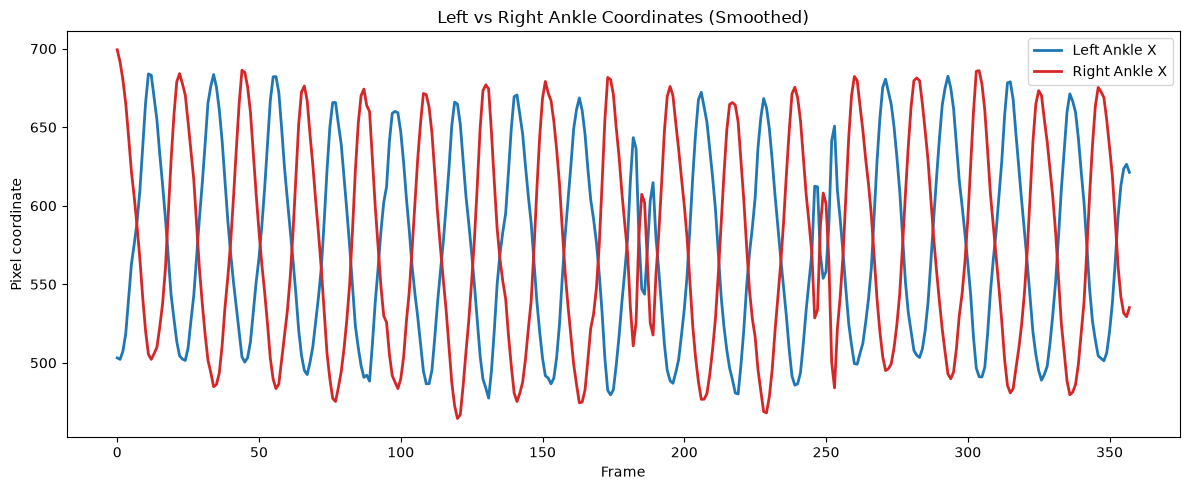

In [14]:
# Left ankle
x_raw_L, y_raw_L, conf_L = extract_ankle_coords(processed_frames, LEFT_ANKLE)
x_filled_L = interpolate_missing(x_raw_L, label="Left ankle X")
y_filled_L = interpolate_missing(y_raw_L, label="Left ankle Y")
x_smooth_L = smooth_coords(x_filled_L)
y_smooth_L = smooth_coords(y_filled_L)

# plot_ankle_coords(x_raw_L, y_raw_L, x_smooth_L, y_smooth_L, label="Left Ankle")

# Right ankle
x_raw_R, y_raw_R, conf_R = extract_ankle_coords(processed_frames, RIGHT_ANKLE)
x_filled_R = interpolate_missing(x_raw_R, label="Right ankle X")
y_filled_R = interpolate_missing(y_raw_R, label="Right ankle Y")
x_smooth_R = smooth_coords(x_filled_R)
y_smooth_R = smooth_coords(y_filled_R)

# plot_ankle_coords(x_raw_R, y_raw_R, x_smooth_R, y_smooth_R, label="Right Ankle")
plot_both_ankles(x_smooth_L, y_smooth_L, x_smooth_R, y_smooth_R)